# Preprocessing and Baseline

## Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load dataset

In [2]:
# Load dataset
import pandas as pd
import os

drive_path = '/content/drive/MyDrive/June/Final Project - Retinal Screening Triage System/data/raw/'
train_csv = pd.read_csv(os.path.join(drive_path, 'train.csv'))

print(f"Rows: {len(train_csv)}")
train_csv.head()

Rows: 3662


,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


Stratified train/val/test split 70/15/15

In [3]:
from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temp (val + test)
train_df, temp_df = train_test_split(
    train_csv,
    test_size=0.30,
    stratify=train_csv['diagnosis'],
    random_state=42
)

# Second split: divide the 30% into 15% val, 15% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['diagnosis'],
    random_state=42
)

print(f"Train: {len(train_df)} ({len(train_df)/len(train_csv)*100:.1f}%)")
print(f"Val:   {len(val_df)} ({len(val_df)/len(train_csv)*100:.1f}%)")
print(f"Test:  {len(test_df)} ({len(test_df)/len(train_csv)*100:.1f}%)")

print("\nClass distribution per split:")
for name, df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f"\n{name}:")
    print(df['diagnosis'].value_counts().sort_index())

Train: 2563 (70.0%)
Val:   549 (15.0%)
Test:  550 (15.0%)

Class distribution per split:

Train:
diagnosis
0    1263
1     259
2     699
3     135
4     207
Name: count, dtype: int64

Val:
diagnosis
0    271
1     55
2    150
3     29
4     44
Name: count, dtype: int64

Test:
diagnosis
0    271
1     56
2    150
3     29
4     44
Name: count, dtype: int64


Note on splitting strategy

The split is stratified by `diagnosis` grade to preserve class proportions
across train/val/test, which is essential given the severe imbalance
(grade 3 has only 193 total images).

**Known limitation**: APTOS 2019 provides no patient identifier, so
patient-level splitting is not possible. If the dataset contains multiple
images from the same patient (e.g. both eyes), those images could be split
across different sets, creating potential data leakage. This is a known
limitation of the dataset itself, not of the splitting method used here.

Copy images to local VM disk for fast access (avoids slow Drive reads)

In [4]:
import shutil, time

local_path = '/content/train_images/'
start = time.time()
shutil.copytree(os.path.join(drive_path, 'train_images'), local_path, dirs_exist_ok=True)
print(f"Copied to local disk in {time.time()-start:.1f}s")

Copied to local disk in 362.6s


## Preprocessing function: resize 224x224 + normalisation

In [5]:
import tensorflow as tf

IMG_SIZE = 224

def load_and_preprocess_image(id_code, label):
    img_path = tf.strings.join([local_path, id_code, '.png'])
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = img / 255.0
    return img, label

## Quick sanity check on one image

In [6]:
sample_path = local_path + train_df.iloc[0]['id_code'] + '.png'
img, label = load_and_preprocess_image(train_df.iloc[0]['id_code'], train_df.iloc[0]['diagnosis'])
print(f"Shape: {img.shape}, dtype: {img.dtype}, range: [{img.numpy().min():.2f}, {img.numpy().max():.2f}]")
print(f"Label: {label}")

Shape: (224, 224, 3), dtype: <dtype: 'float32'>, range: [0.02, 1.00]
Label: 0


Augmentation: rotation, horizontal flip only, brightness, zoom

In [7]:
def augment_image(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=0.1)
    img = tf.clip_by_value(img, 0.0, 1.0)  # keep values in valid [0,1] range after brightness shift
    img = tf.image.rot90(img, k=tf.random.uniform([], 0, 4, dtype=tf.int32))
    return img, label

Note: `clip_by_value` after `random_brightness` is necessary because
brightness adjustment can push pixel values outside the valid [0,1] range
(observed via matplotlib clipping warnings during visual inspection).

Build tf.data pipelines with batching and prefetch

In [8]:
BATCH_SIZE = 32

def build_dataset(df, augment=False, shuffle=False):
    ids = df['id_code'].values
    labels = df['diagnosis'].values

    ds = tf.data.Dataset.from_tensor_slices((ids, labels))
    ds = ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)

    if augment:
        ds = ds.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=len(df))

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = build_dataset(train_df, augment=True, shuffle=True)
val_ds = build_dataset(val_df, augment=False, shuffle=False)
test_ds = build_dataset(test_df, augment=False, shuffle=False)

print("Datasets built successfully")
for images, labels in train_ds.take(1):
    print(f"Batch shape: {images.shape}, labels shape: {labels.shape}")

Datasets built successfully
Batch shape: (32, 224, 224, 3), labels shape: (32,)


 Visually inspect one augmented batch

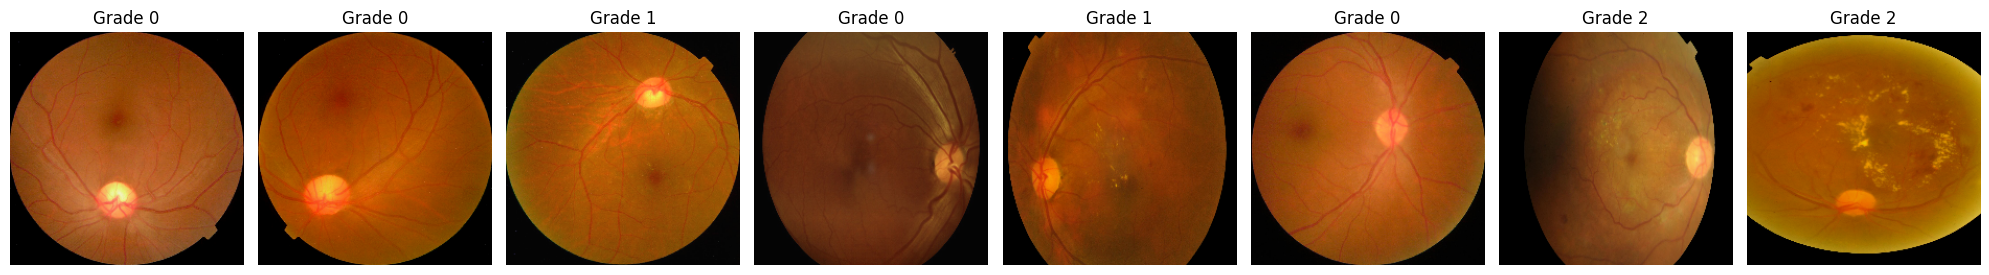

In [9]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
    fig, axes = plt.subplots(1, 8, figsize=(20, 3))
    for i in range(8):
        axes[i].imshow(images[i])
        axes[i].set_title(f'Grade {labels[i].numpy()}')
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

# Evaluation metric: Quadratic Weighted Kappa

In [10]:
from sklearn.metrics import cohen_kappa_score, confusion_matrix, classification_report
import numpy as np

def evaluate_predictions(y_true, y_pred):
    """
    Compute QWK, confusion matrix, and per-class recall.
    y_true, y_pred: arrays of integer grades (0-4)
    """
    qwk = cohen_kappa_score(y_true, y_pred, weights='quadratic')
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, output_dict=True)

    print(f"Quadratic Weighted Kappa: {qwk:.4f}")
    print("\nConfusion matrix:")
    print(cm)
    print("\nPer-class recall:")
    for grade in range(5):
        recall = report[str(grade)]['recall']
        print(f"  Grade {grade}: {recall:.3f}")

    return qwk, cm, report

Sanity check: perfect predictions should give QWK close to 1.0, poor predictions should give a low or negative value.

In [11]:
y_true_test = np.array([0, 1, 2, 3, 4, 0, 1, 2])
y_pred_perfect = y_true_test.copy()
y_pred_random = np.array([4, 0, 3, 1, 0, 2, 4, 3])

print("Perfect predictions:")
evaluate_predictions(y_true_test, y_pred_perfect)

print("\n" + "="*40)
print("Bad predictions:")
evaluate_predictions(y_true_test, y_pred_random)

Perfect predictions:
Quadratic Weighted Kappa: 1.0000

Confusion matrix:
[[2 0 0 0 0]
 [0 2 0 0 0]
 [0 0 2 0 0]
 [0 0 0 1 0]
 [0 0 0 0 1]]

Per-class recall:
  Grade 0: 1.000
  Grade 1: 1.000
  Grade 2: 1.000
  Grade 3: 1.000
  Grade 4: 1.000

Bad predictions:
Quadratic Weighted Kappa: -0.4964

Confusion matrix:
[[0 0 1 0 1]
 [1 0 0 0 1]
 [0 0 0 2 0]
 [0 1 0 0 0]
 [1 0 0 0 0]]

Per-class recall:
  Grade 0: 0.000
  Grade 1: 0.000
  Grade 2: 0.000
  Grade 3: 0.000
  Grade 4: 0.000


(np.float64(-0.49640287769784175),
 array([[0, 0, 1, 0, 1],
        [1, 0, 0, 0, 1],
        [0, 0, 0, 2, 0],
        [0, 1, 0, 0, 0],
        [1, 0, 0, 0, 0]]),
 {'0': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 2.0},
  '1': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 2.0},
  '2': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 2.0},
  '3': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 1.0},
  '4': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 1.0},
  'accuracy': 0.0,
  'macro avg': {'precision': 0.0,
   'recall': 0.0,
   'f1-score': 0.0,
   'support': 8.0},
  'weighted avg': {'precision': 0.0,
   'recall': 0.0,
   'f1-score': 0.0,
   'support': 8.0}})

Class weights for imbalance

In [12]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['diagnosis']),
    y=train_df['diagnosis']
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(0.4058590657165479), 1: np.float64(1.9791505791505792), 2: np.float64(0.7333333333333333), 3: np.float64(3.797037037037037), 4: np.float64(2.476328502415459)}


# Baseline CNN

Set random seed for reproducibility

In [15]:
import numpy as np

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

Baseline CNN — simple architecture from scratch

In [16]:
from tensorflow.keras import layers, models

model_baseline = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(5, activation='softmax')  # 5 ICDRSS grades
])

model_baseline.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_baseline.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,605 (42.61 MB)

 Trainable params: 11,169,605 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Train baseline with EarlyStopping and class weights

In [17]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_baseline = model_baseline.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)

Epoch 1/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 228s 613ms/step - accuracy: 0.5275 - loss: 1.4688 - val_accuracy: 0.5811 - val_loss: 1.0335
Epoch 2/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 213s 571ms/step - accuracy: 0.5669 - loss: 1.2910 - val_accuracy: 0.5738 - val_loss: 1.0154
Epoch 3/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 210s 508ms/step - accuracy: 0.5845 - loss: 1.2664 - val_accuracy: 0.6029 - val_loss: 1.0428
Epoch 4/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 265s 571ms/step - accuracy: 0.5841 - loss: 1.2483 - val_accuracy: 0.5756 - val_loss: 1.0501
Epoch 5/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 265s 570ms/step - accuracy: 0.6098 - loss: 1.2523 - val_accuracy: 0.6011 - val_loss: 1.0709


Evaluate baseline on validation set

In [18]:
# Get true labels and predictions on validation set
y_val_true = []
y_val_pred = []

for images, labels in val_ds:
    preds = model_baseline.predict(images, verbose=0)
    y_val_pred.extend(np.argmax(preds, axis=1))
    y_val_true.extend(labels.numpy())

y_val_true = np.array(y_val_true)
y_val_pred = np.array(y_val_pred)

qwk_baseline, cm_baseline, report_baseline = evaluate_predictions(y_val_true, y_val_pred)

Quadratic Weighted Kappa: 0.4972

Confusion matrix:
[[203  42   6   1  19]
 [  5  38   2   1   9]
 [  8  53  60   0  29]
 [  0  10   5   3  11]
 [  2  19  11   1  11]]

Per-class recall:
  Grade 0: 0.749
  Grade 1: 0.691
  Grade 2: 0.400
  Grade 3: 0.103
  Grade 4: 0.250


## Baseline summary

The baseline CNN (trained from scratch) reaches QWK 0.4972 on the
validation set, with strong recall on the majority class (Grade 0: 0.749)
but poor recall on minority/critical classes — notably Grade 3 (0.103),
the severe retinopathy grade where false negatives carry the highest
clinical cost.

This establishes the baseline to beat and motivates transfer learning with
EfficientNetB0, explored in `03_transfer_learning.ipynb`.